# EDA del dataset di fatture

Questo notebook esplora in modo semplice il file `invoices_dataset.json` scaricato da Kaggle.

Obiettivi:
- capire la struttura del JSON;
- trasformare le fatture in tabelle pandas;
- creare alcune tabelle riassuntive;
- visualizzare pochi grafici chiari con matplotlib.

## 1. Import e configurazione

In [19]:
import os
import json
from pathlib import Path

# Evita warning di matplotlib se la home utente non e' scrivibile.
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib_cache").resolve()))

import matplotlib.pyplot as plt
import pandas as pd

# Mostriamo qualche colonna in piu' quando stampiamo i DataFrame.
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

# Percorso del file JSON. Il notebook si trova in ai-invoice-matching/notebooks.
DATA_PATH = Path("..") / "data" / "raw" / "invoices_dataset.json"

DATA_PATH

WindowsPath('../data/raw/invoices_dataset.json')

## 2. Caricamento del JSON

Il file contiene una lista di esempi. Ogni esempio ha un nome immagine e una conversazione. La risposta `gpt` contiene la fattura vera e propria in formato JSON testuale.

In [20]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(f"Numero di record nel file: {len(raw_data):,}")
print("Chiavi del primo record:", list(raw_data[0].keys()))
raw_data[0]

Numero di record nel file: 7,000
Chiavi del primo record: ['image', 'conversations']


{'image': '001.png',
 'conversations': [{'from': 'human', 'value': '<image>\nExtract JSON'},
  {'from': 'gpt',
   'value': '{"buyer": {"address": "960 Hurley Springs North Alyssa, RI 49322", "company_name": "Hayes LLC", "country": "Lebanon", "name": "Mercedes Martinez"}, "invoice": {"date": "05.08.2007", "number": 802205}, "payment": {"discount_amount": 43.03, "discount_percentage": 11.77, "due": 61.79, "sub_total": 141.66, "total": 534.11}, "products": [{"description": "transform open-source info-mediaries", "index": "10", "quantity": 6.27, "total_price": 329.62, "unit_price": 41.57}, {"description": "innovate transparent e-services", "index": "9", "quantity": 5.62, "total_price": 986.28, "unit_price": 10.47}, {"description": "optimize innovative action-items", "index": "3", "quantity": 7.11, "total_price": 559.69, "unit_price": 97.41}, {"description": "enhance e-business initiatives", "index": "10", "quantity": 4.75, "total_price": 311.4, "unit_price": 88.26}, {"description": "morph 

## 3. Estrazione delle fatture

Per ogni record prendiamo il messaggio prodotto da `gpt` e lo convertiamo da stringa JSON a dizionario Python.

In [21]:
def get_gpt_json_text(record):
    """Restituisce il testo JSON contenuto nella risposta GPT di un record."""
    for message in record.get("conversations", []):
        if message.get("from") == "gpt":
            return message.get("value")
    return None


parsed_rows = []
parse_errors = []

for i, record in enumerate(raw_data):
    gpt_text = get_gpt_json_text(record)
    try:
        invoice_json = json.loads(gpt_text)
        invoice_json["image"] = record.get("image")
        parsed_rows.append(invoice_json)
    except Exception as exc:
        parse_errors.append({"row": i, "image": record.get("image"), "error": str(exc)})

print(f"Fatture parsate correttamente: {len(parsed_rows):,}")
print(f"Fatture con errore di parsing: {len(parse_errors):,}")

Fatture parsate correttamente: 7,000
Fatture con errore di parsing: 0


## 4. Creazione delle tabelle pandas

Creiamo due tabelle:
- `invoices_df`: una riga per fattura;
- `products_df`: una riga per prodotto/linea fattura.

In [22]:
# Normalizziamo i campi annidati come buyer.company_name, seller.vat_no, payment.total, ecc.
invoices_df = pd.json_normalize(parsed_rows)

# Il campo products e' una lista: lo togliamo dalla tabella principale e lo gestiamo a parte.
invoices_df["n_products"] = invoices_df["products"].apply(lambda x: len(x) if isinstance(x, list) else 0)
invoices_df = invoices_df.drop(columns=["products"])

product_rows = []
for invoice in parsed_rows:
    for product in invoice.get("products", []):
        row = product.copy()
        row["image"] = invoice.get("image")
        row["invoice_number"] = invoice.get("invoice", {}).get("number")
        row["invoice_date"] = invoice.get("invoice", {}).get("date")
        product_rows.append(row)

products_df = pd.DataFrame(product_rows)

print("Dimensione invoices_df:", invoices_df.shape)
print("Dimensione products_df:", products_df.shape)

Dimensione invoices_df: (7000, 68)
Dimensione products_df: (28067, 17)


In [23]:
invoices_df.head()

,image,buyer.address,buyer.company_name,buyer.country,buyer.name,invoice.date,invoice.number,payment.discount_amount,payment.discount_percentage,payment.due,payment.sub_total,payment.total,seller.address,seller.company_name,seller.vat_no,buyer.email,buyer.phone,buyer.vat_no,invoice.due_date,invoice.market_reference,invoice.notes,invoice.reference,invoice.vat_no,payment.net_total,seller.email,seller.name,tax.base,tax.tax_amount,tax.total_tax,payment.account_number,payment.bank_name,payment.routing_number,invoice.linked_invoice,seller.ape,seller.capital,seller.country,seller.phone_1,seller.phone_2,seller.phone_3,seller.ref_walk,seller.reference,seller.siret,seller.website,tax.amount_0,tax.amount_1,tax.base_0,tax.base_1,tax.total_ht,tax.total_ttc,tax.vat_0,tax.vat_1,invoice.bc_no,invoice.maturity_date,tax.amount_excluding_tax,tax.amount_including_tax,buyer.id,invoice.currency_code,payment.bic,payment.iban,supplier.address,supplier.name,buyer.business_no,payment.due_date,tax.base_ht,tax.regulations,tax.vat_amount,tax.vat_percentage,n_products
0,001.png,"960 Hurley Springs North Alyssa, RI 49322",Hayes LLC,Lebanon,Mercedes Martinez,05.08.2007,802205,43.03,11.77,61.79,141.66,534.11,"60464 Curtis Gateway East Keith, IN 57123","Lopez, Miller and Romero",Qu96730920377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
1,002.png,Unit 1426 Box 5236 DPO AE 74575,Wilson PLC,Armenia,Diane Myers,10.01.2012,706585,12.63,16.08,97.60,172.27,756.81,"66379 Antonio Roads Shieldsberg, SC 06919",Williams PLC,TN21504218908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,003.png,"219 Hall Plaza Emilymouth, TN 77611",Mcbride Inc,Taiwan,Melissa Miller,23.12.1991,436251,38.39,6.65,136.96,151.41,350.83,"338 Cody Grove North Cody, CO 58039",Williams-Johnson,hV85479687918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,004.png,"44126 Claudia Mount Suite 784 Morrisfort, IA 95132","Barnett, White and James",Lao People's Democratic Republic,Nicole Martin,02.10.1993,807426,23.88,8.10,89.63,63.54,704.26,"45838 Stephens Stream East Jessica, KY 44332",Holt-Mercado,kz32957163737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,005.png,"19780 Miller Rest Apt. 044 West Kristenfurt, MT 95623",Sanchez Inc,Kenya,Ryan Davis,16.07.2011,614625,18.49,18.56,113.98,168.65,699.63,"05329 Montgomery Summit East Anthonymouth, CT 11866",Garza-Norris,Rc33944645425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7


In [24]:
products_df.head()

,description,index,quantity,total_price,unit_price,image,invoice_number,invoice_date,amount,hours,rate,discount_percentage,price,vat_amount,tax_amount,total_ttc,reference
0,transform open-source info-mediaries,10,6.27,329.62,41.57,001.png,802205,05.08.2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,innovate transparent e-services,9,5.62,986.28,10.47,001.png,802205,05.08.2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,optimize innovative action-items,3,7.11,559.69,97.41,001.png,802205,05.08.2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,enhance e-business initiatives,10,4.75,311.40,88.26,001.png,802205,05.08.2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,morph value-added markets,2,8.39,831.07,65.07,001.png,802205,05.08.2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Tabelle riassuntive

In [25]:
summary_table = pd.DataFrame({
    "metrica": [
        "record nel JSON originale",
        "fatture parsate",
        "fatture non parsate",
        "righe prodotto",
        "prodotti medi per fattura",
        "colonne tabella fatture",
        "colonne tabella prodotti",
    ],
    "valore": [
        len(raw_data),
        len(invoices_df),
        len(parse_errors),
        len(products_df),
        round(invoices_df["n_products"].mean(), 2),
        invoices_df.shape[1],
        products_df.shape[1],
    ],
})

summary_table

,metrica,valore
0,record nel JSON originale,7000.00
1,fatture parsate,7000.00
2,fatture non parsate,0.00
3,righe prodotto,28067.00
4,prodotti medi per fattura,4.01
5,colonne tabella fatture,68.00
6,colonne tabella prodotti,17.00


### Copertura dei campi

Questa tabella mostra in quante fatture e' presente ogni campo. E' utile per capire quali informazioni sono sempre disponibili e quali no.

In [26]:
field_coverage = (
    invoices_df.notna().mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"index": "campo", 0: "percentuale_presenza"})
    .sort_values("percentuale_presenza", ascending=False)
)

field_coverage.head(30)

,campo,percentuale_presenza
0,image,100.0
1,buyer.address,100.0
6,invoice.number,100.0
5,invoice.date,100.0
67,n_products,100.0
12,seller.address,85.7
18,invoice.due_date,57.1
2,buyer.company_name,42.9
27,tax.tax_amount,42.9
15,buyer.email,42.9


### Statistiche sui prodotti per fattura

In [27]:
invoices_df["n_products"].describe().to_frame("n_products")

,n_products
count,7000.000000
mean,4.009571
std,1.995937
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,7.000000


### Campi numerici principali

Convertiamo alcune colonne in numerico. Usiamo `errors="coerce"` per trasformare eventuali valori non convertibili in `NaN`.

In [28]:
invoice_numeric_cols = [
    "payment.total",
    "payment.sub_total",
    "payment.due",
    "payment.discount_amount",
    "payment.discount_percentage",
    "payment.net_total",
    "tax",
]

for col in invoice_numeric_cols:
    if col in invoices_df.columns:
        invoices_df[col] = pd.to_numeric(invoices_df[col], errors="coerce")

available_invoice_numeric_cols = [col for col in invoice_numeric_cols if col in invoices_df.columns]
invoices_df[available_invoice_numeric_cols].describe().round(2)

,payment.total,payment.sub_total,payment.due,payment.discount_amount,payment.discount_percentage,payment.net_total
count,3000.00,1001.00,1001.00,1001.00,1001.00,1000.00
mean,556.37,112.58,106.31,29.25,12.56,109.91
std,259.57,50.86,53.81,11.71,4.29,52.98
min,100.19,20.01,10.08,10.02,5.01,20.03
25%,333.22,66.77,60.90,18.83,8.66,62.90
50%,554.62,115.64,106.66,28.87,12.58,110.87
75%,782.02,154.75,153.67,38.88,16.03,156.62
max,999.95,199.91,199.91,49.99,19.98,199.96


In [29]:
product_numeric_cols = [
    "quantity",
    "unit_price",
    "price",
    "amount",
    "total_price",
    "vat_amount",
    "tax_amount",
    "discount_percentage",
    "hours",
    "rate",
]

for col in product_numeric_cols:
    if col in products_df.columns:
        products_df[col] = pd.to_numeric(products_df[col], errors="coerce")

available_product_numeric_cols = [col for col in product_numeric_cols if col in products_df.columns]
products_df[available_product_numeric_cols].describe().round(2)

,quantity,unit_price,price,amount,total_price,vat_amount,tax_amount,discount_percentage,hours,rate
count,24025.00,19970.00,8124.00,19956.00,4042.00,7972.00,4055.00,4069.00,4042.00,4042.00
mean,5.49,54.75,251.16,251.84,508.93,5.27,55.70,12.44,5.41,5.49
std,2.60,26.14,143.66,143.35,288.11,4.13,25.57,4.27,2.60,2.60
min,1.00,10.00,5.02,5.03,10.11,0.00,10.08,5.01,1.00,1.00
25%,3.24,32.24,124.63,125.75,257.02,1.90,34.08,8.80,3.17,3.24
50%,5.45,54.53,250.61,252.20,513.62,4.25,55.21,12.36,5.35,5.44
75%,7.76,77.55,375.51,376.61,758.35,7.81,77.78,16.14,7.68,7.75
max,10.00,100.00,499.97,499.99,999.98,18.85,99.99,19.99,10.00,10.00


### Campo paese del buyer

Il campo `buyer.country` e' spesso mancante. Per questo lo guardiamo con una tabellina, senza farne un grafico.

In [30]:
if "buyer.country" in invoices_df.columns:
    buyer_country_summary = pd.DataFrame({
        "metrica": ["valori presenti", "valori mancanti", "percentuale mancante"],
        "valore": [
            invoices_df["buyer.country"].notna().sum(),
            invoices_df["buyer.country"].isna().sum(),
            round(invoices_df["buyer.country"].isna().mean() * 100, 1),
        ],
    })

    display(buyer_country_summary)

    buyer_country_values = (
        invoices_df["buyer.country"]
        .value_counts(dropna=False)
        .head(10)
        .rename_axis("buyer_country")
        .reset_index(name="numero_fatture")
    )
    display(buyer_country_values)
else:
    print("Campo buyer.country non presente nel dataset.")

,metrica,valore
0,valori presenti,2001.0
1,valori mancanti,4999.0
2,percentuale mancante,71.4


,buyer_country,numero_fatture
0,NaN,4999
1,Congo,24
2,Japan,19
3,Honduras,16
4,Korea,16
5,Palestinian Territory,16
6,Argentina,15
7,Seychelles,15
8,Martinique,15
9,Samoa,15


### Anni delle fatture

Le date sembrano essere in formato giorno/mese/anno o simile. Usiamo `dayfirst=True` per interpretarle in modo piu' naturale per dati europei.

In [31]:
invoices_df["invoice.date_parsed"] = pd.to_datetime(
    invoices_df["invoice.date"],
    errors="coerce",
    dayfirst=True,
)

invoice_years = (
    invoices_df["invoice.date_parsed"]
    .dt.year
    .value_counts()
    .sort_index()
    .rename_axis("anno")
    .reset_index(name="numero_fatture")
)

invoice_years.head(20)

,anno,numero_fatture
0,1990,203
1,1991,220
2,1992,187
3,1993,221
4,1994,192
5,1995,221
6,1996,216
7,1997,208
8,1998,193
9,1999,210


## 6. Grafici con matplotlib

### Distribuzione del numero di prodotti per fattura

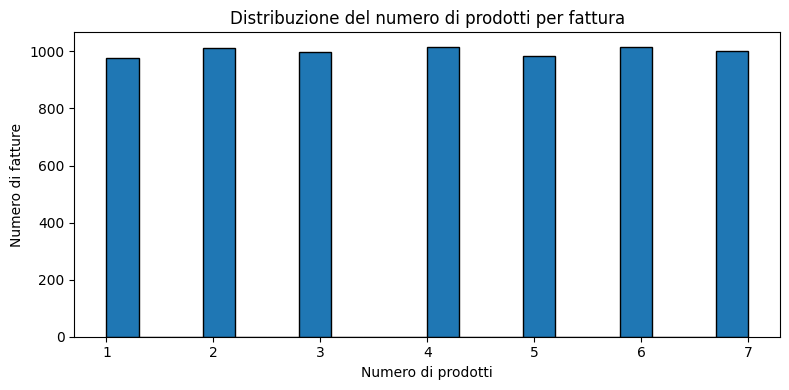

In [32]:
plt.figure(figsize=(8, 4))
plt.hist(invoices_df["n_products"], bins=20, edgecolor="black")
plt.title("Distribuzione del numero di prodotti per fattura")
plt.xlabel("Numero di prodotti")
plt.ylabel("Numero di fatture")
plt.tight_layout()
plt.show()

### Distribuzione del totale fattura

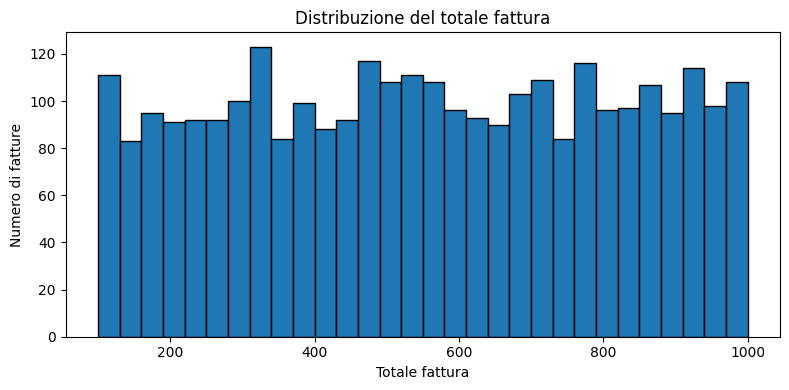

In [33]:
if "payment.total" in invoices_df.columns:
    totals = invoices_df["payment.total"].dropna()

    plt.figure(figsize=(8, 4))
    plt.hist(totals, bins=30, edgecolor="black")
    plt.title("Distribuzione del totale fattura")
    plt.xlabel("Totale fattura")
    plt.ylabel("Numero di fatture")
    plt.tight_layout()
    plt.show()
else:
    print("Campo payment.total non presente nel dataset.")

### Campi mancanti nei prodotti

Questa tabella mostra quanti valori mancano nella tabella `products_df` per ogni campo prodotto.

In [34]:
product_missing_table = (
    products_df.isna().sum()
    .reset_index()
    .rename(columns={"index": "campo", 0: "valori_mancanti"})
)
product_missing_table["percentuale_mancante"] = (
    product_missing_table["valori_mancanti"] / len(products_df) * 100
).round(1)

product_missing_table.sort_values("percentuale_mancante", ascending=False)

,campo,valori_mancanti,percentuale_mancante
16,reference,24049,85.7
10,rate,24025,85.6
3,total_price,24025,85.6
9,hours,24025,85.6
14,tax_amount,24012,85.6
15,total_ttc,24012,85.6
11,discount_percentage,23998,85.5
13,vat_amount,20095,71.6
12,price,19943,71.1
1,index,16046,57.2


### Copertura dei campi prodotto

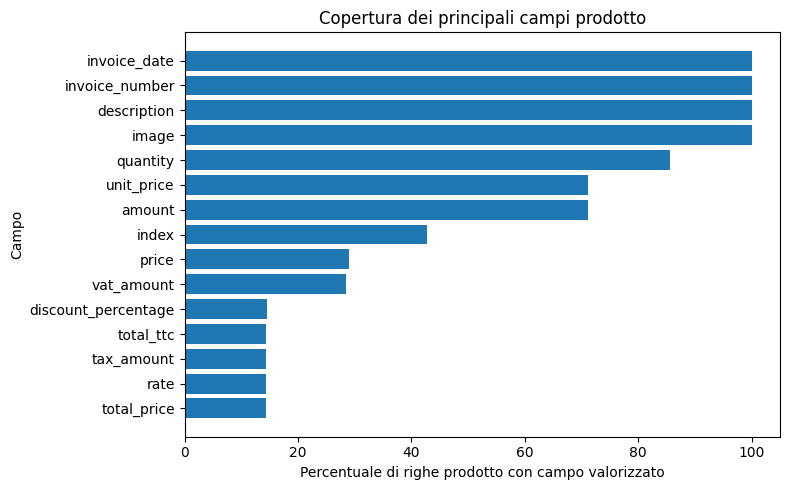

In [35]:
product_field_coverage = (
    products_df.notna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.barh(product_field_coverage.index, product_field_coverage.values)
plt.title("Copertura dei principali campi prodotto")
plt.xlabel("Percentuale di righe prodotto con campo valorizzato")
plt.ylabel("Campo")
plt.tight_layout()
plt.show()

## 7. Prime osservazioni

Punti da controllare durante l'EDA:
- Il dataset ha 7.000 record, ognuno collegato a un'immagine di fattura.
- La parte strutturata e' contenuta nel messaggio `gpt` e puo' essere parsata come JSON.
- I campi non sono tutti presenti in tutte le fatture: la copertura dei campi e' quindi importante.
- Il campo `buyer.country` e' spesso mancante, quindi va interpretato con cautela.
- La tabella prodotti e' separata dalla tabella fatture perche' una fattura puo' contenere piu' righe prodotto.
- Alcuni campi monetari hanno nomi diversi tra fatture/prodotti: per analisi piu' avanzate si potrebbe fare una normalizzazione dei nomi.